# Final Project Pipeline

This notebook runs the optimizer, reviews scenario-level outputs, and runs Monte Carlo simulation for one selected scenario.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / 'data').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from factor_covariance_benchmark import benchmark_covariance_methods
from mip_bond_optimizer import run_all_scenarios
from monte_carlo_engine import run_monte_carlo
from solver_comparison import run_solver_comparison
from stress_testing_engine import build_return_shock_portfolio, build_stress_covariance, run_stress_tests

data_dir = repo_root / 'data'
output_dir = repo_root / 'outputs'
output_dir.mkdir(exist_ok=True)


In [2]:
bond_universe = pd.read_csv(data_dir / 'synthetic_bond_universe.csv')
cov_matrix = pd.read_csv(data_dir / 'synthetic_covariance_matrix.csv', index_col=0)
scenario_results = run_all_scenarios(bond_universe, cov_matrix=cov_matrix)


Running Bond Scenario: Portfolio 1 — ~$50M target value, medium time horizon
Status: Optimal Solution Found
Portfolio Expected Return ($): 2,428,903.75000
Solve Time: 0.25730 seconds
Selected Bonds: 4
Portfolio Volatility: 0.084422

Running Bond Scenario: Portfolio 2 — ~$20M target value, short time horizon, risk-averse

Running Bond Scenario: Portfolio 3 — ~$100M target value, long time horizon, moderate/high risk
Status: Optimal Solution Found
Portfolio Expected Return ($): 4,632,616.70000
Solve Time: 0.14896 seconds
Selected Bonds: 4
Portfolio Volatility: 0.091100



In [3]:
summary_rows = []
for scenario_id, result in scenario_results.items():
    if result.get('status') != 'Optimal':
        continue
    summary_rows.append({
        'scenario_id': scenario_id,
        'scenario_name': result['scenario_name'],
        'objective_value': result['objective_value'],
        'solve_time_seconds': result['solve_time_seconds'],
        **result['summary_metrics'],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,scenario_id,scenario_name,objective_value,solve_time_seconds,selected_bond_count,total_face_value,weighted_expected_return_pct,weighted_liquidity_score,weighted_maturity_years,weighted_annual_volatility_pct,portfolio_variance,portfolio_volatility
0,1,"Portfolio 1 — ~$50M target value, medium time ...",2428903.75,0.257302,4,50500000.0,4.809710,0.891025,15.636045,4.999993,0.007127,0.084422
1,3,"Portfolio 3 — ~$100M target value, long time h...",4632616.70,0.148965,4,101500000.0,4.564154,0.907146,17.245162,4.999914,0.008299,0.091100


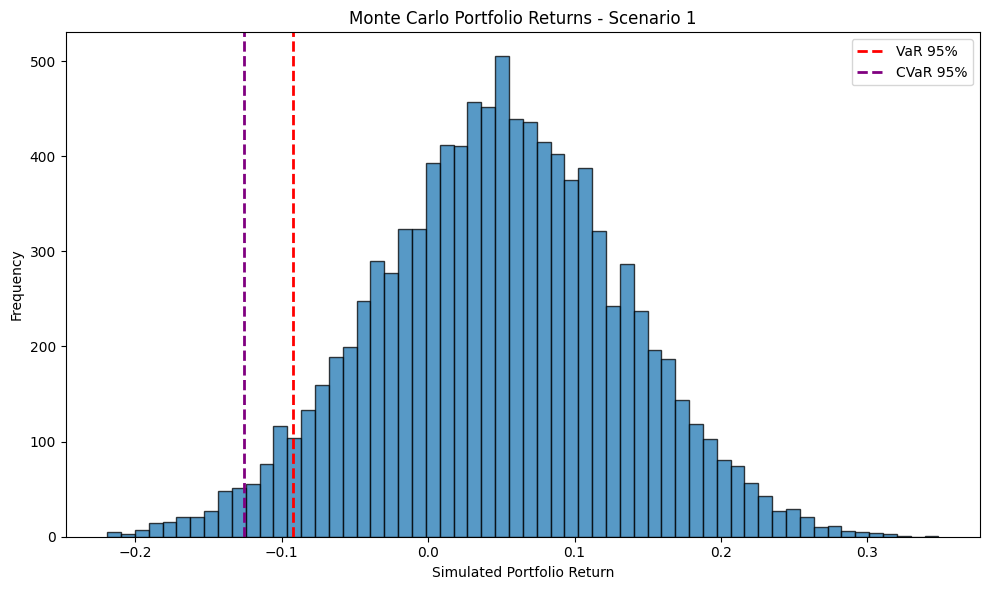

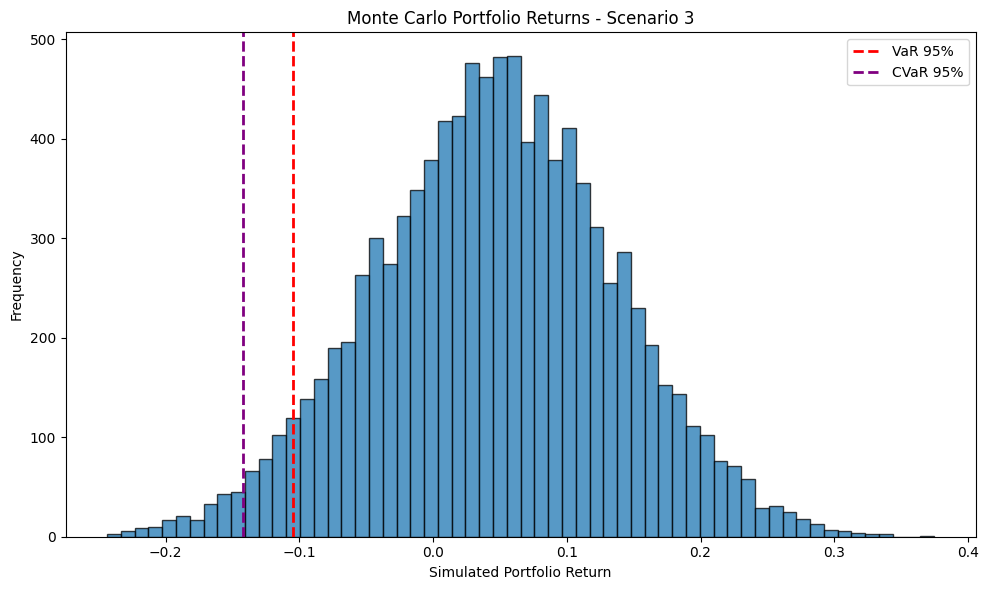

,scenario_id,confidence_level,mean_return,std_return,min_return,max_return,var,cvar,portfolio_csv,mc_returns_csv,mc_metrics_csv,histogram_png
0,1,0.95,0.048188,0.083596,-0.219063,0.348457,0.092103,0.125765,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...
1,1,0.99,0.048188,0.083596,-0.219063,0.348457,0.147262,0.172482,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...
2,3,0.95,0.045731,0.090214,-0.243951,0.374759,0.104992,0.141872,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...
3,3,0.99,0.045731,0.090214,-0.243951,0.374759,0.165707,0.192291,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...


In [4]:
all_mc_rows = []

for scenario_id, result in scenario_results.items():
    if result.get("status") != "Optimal":
        continue

    portfolio_df = result["portfolio_df"]

    # Save optimized portfolio
    portfolio_path = output_dir / f"portfolio_scenario_{scenario_id}.csv"
    portfolio_df.to_csv(portfolio_path, index=False)

    # Run Monte Carlo
    mc_result = run_monte_carlo(portfolio_df, cov_matrix)
    mc_returns_df = mc_result["simulated_returns"]
    mc_metrics_df = mc_result["metrics"]

    # Save Monte Carlo outputs
    returns_path = output_dir / f"mc_returns_scenario_{scenario_id}.csv"
    metrics_path = output_dir / f"mc_metrics_scenario_{scenario_id}.csv"

    mc_returns_df.to_csv(returns_path, index=False)
    mc_metrics_df.to_csv(metrics_path, index=False)

    # Plot MC histogram
    returns = mc_returns_df["simulated_portfolio_return"]

    var_95 = mc_metrics_df.loc[
        mc_metrics_df["confidence_level"] == 0.95, "var"
    ].iloc[0]

    cvar_95 = mc_metrics_df.loc[
        mc_metrics_df["confidence_level"] == 0.95, "cvar"
    ].iloc[0]

    plt.figure(figsize=(10, 6))
    plt.hist(returns, bins=60, alpha=0.75, edgecolor="black")

    # If var/cvar are stored as positive loss numbers, keep the negative sign.
    # If they are already return quantiles, remove the minus signs.
    plt.axvline(-var_95, color="red", linestyle="--", linewidth=2, label="VaR 95%")
    plt.axvline(-cvar_95, color="purple", linestyle="--", linewidth=2, label="CVaR 95%")

    plt.title(f"Monte Carlo Portfolio Returns - Scenario {scenario_id}")
    plt.xlabel("Simulated Portfolio Return")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()

    figure_path = output_dir / f"scenario_{scenario_id}_mc_histogram.png"
    plt.savefig(figure_path, dpi=150)
    plt.show()

    # Flatten MC metrics into final summary rows
    for _, metric_row in mc_metrics_df.iterrows():
        all_mc_rows.append({
            "scenario_id": scenario_id,
            "confidence_level": metric_row["confidence_level"],
            "mean_return": metric_row.get("mean_return"),
            "std_return": metric_row.get("std_return"),
            "min_return": metric_row.get("min_return"),
            "max_return": metric_row.get("max_return"),
            "var": metric_row["var"],
            "cvar": metric_row["cvar"],
            "portfolio_csv": str(portfolio_path),
            "mc_returns_csv": str(returns_path),
            "mc_metrics_csv": str(metrics_path),
            "histogram_png": str(figure_path),
        })

mc_summary_df = pd.DataFrame(all_mc_rows)
mc_summary_df.to_csv(output_dir / "monte_carlo_summary_all_scenarios.csv", index=False)

summary_df.to_csv(output_dir / "scenario_summary.csv", index=False)

mc_summary_df

In [5]:
final_summary_df = summary_df.merge(
    mc_summary_df[mc_summary_df["confidence_level"] == 0.95],
    on="scenario_id",
    how="left"
)

final_summary_df.to_csv(output_dir / "final_project_results_summary.csv", index=False)

final_summary_df

,scenario_id,scenario_name,objective_value,solve_time_seconds,selected_bond_count,total_face_value,weighted_expected_return_pct,weighted_liquidity_score,weighted_maturity_years,weighted_annual_volatility_pct,...,mean_return,std_return,min_return,max_return,var,cvar,portfolio_csv,mc_returns_csv,mc_metrics_csv,histogram_png
0,1,"Portfolio 1 — ~$50M target value, medium time ...",2428903.75,0.257302,4,50500000.0,4.809710,0.891025,15.636045,4.999993,...,0.048188,0.083596,-0.219063,0.348457,0.092103,0.125765,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...
1,3,"Portfolio 3 — ~$100M target value, long time h...",4632616.70,0.148965,4,101500000.0,4.564154,0.907146,17.245162,4.999914,...,0.045731,0.090214,-0.243951,0.374759,0.104992,0.141872,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...,/Users/tanishqsardana/Documents/HW/bond_portfo...


In [6]:
selected_scenario_id = int(summary_df.iloc[0]['scenario_id'])
selected_portfolio = scenario_results[selected_scenario_id]['portfolio_df']
stress_results = run_stress_tests(selected_portfolio, cov_matrix)
stress_metrics_df = pd.concat(stress_results.values(), ignore_index=True)
stress_metrics_df.to_csv(output_dir / f'stress_metrics_scenario_{selected_scenario_id}.csv', index=False)
stress_metrics_df


,scenario,confidence_level,mean_return,std_return,min_return,max_return,var,cvar
0,baseline,0.95,0.048188,0.083596,-0.219063,0.348457,0.092103,0.125765
1,baseline,0.99,0.048188,0.083596,-0.219063,0.348457,0.147262,0.172482
2,covariance_stress,0.95,0.048208,0.102383,-0.279106,0.415961,0.123612,0.164840
3,covariance_stress,0.99,0.048208,0.102383,-0.279106,0.415961,0.191168,0.222056
4,return_shock,0.95,0.038188,0.083596,-0.229063,0.338457,0.102103,0.135765
5,return_shock,0.99,0.038188,0.083596,-0.229063,0.338457,0.157262,0.182482
6,combined_stress,0.95,0.038208,0.102383,-0.289106,0.405961,0.133612,0.174840
7,combined_stress,0.99,0.038208,0.102383,-0.289106,0.405961,0.201168,0.232056


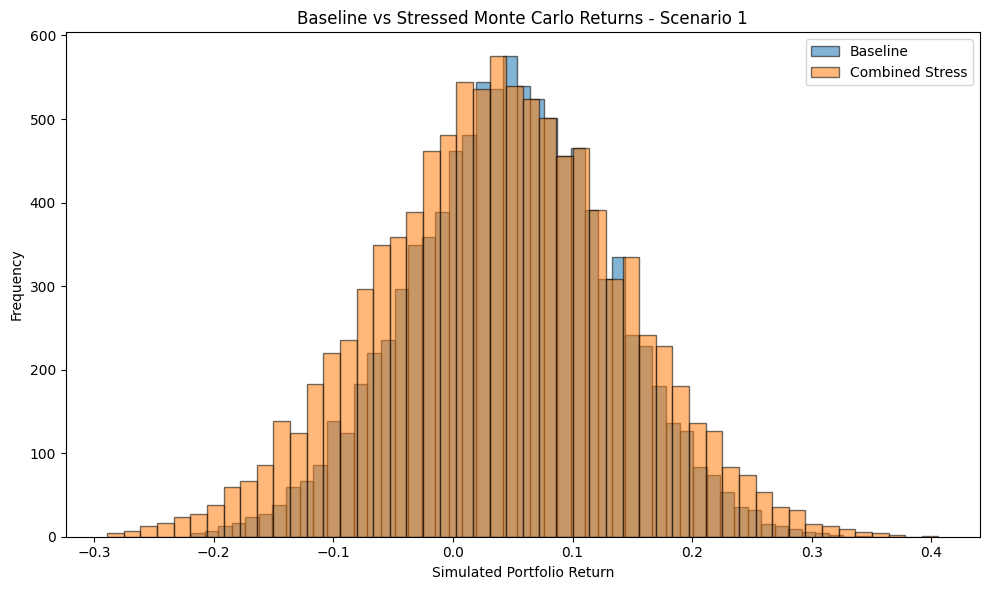

PosixPath('/Users/tanishqsardana/Documents/HW/bond_portfolio_dataset/outputs/scenario_1_stress_histogram.png')

In [7]:
baseline_returns = run_monte_carlo(selected_portfolio, cov_matrix)['simulated_returns']['simulated_portfolio_return']
stressed_cov = build_stress_covariance(cov_matrix)
combined_stress_portfolio = build_return_shock_portfolio(selected_portfolio)
combined_stress_returns = run_monte_carlo(combined_stress_portfolio, stressed_cov)['simulated_returns']['simulated_portfolio_return']

plt.figure(figsize=(10, 6))
plt.hist(baseline_returns, bins=50, alpha=0.55, label='Baseline', edgecolor='black')
plt.hist(combined_stress_returns, bins=50, alpha=0.55, label='Combined Stress', edgecolor='black')
plt.title(f'Baseline vs Stressed Monte Carlo Returns - Scenario {selected_scenario_id}')
plt.xlabel('Simulated Portfolio Return')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
stress_figure_path = output_dir / f'scenario_{selected_scenario_id}_stress_histogram.png'
plt.savefig(stress_figure_path, dpi=150)
plt.show()
stress_figure_path


In [8]:
solver_comparison_df = run_solver_comparison(bond_universe, cov_matrix)
solver_comparison_df.to_csv(output_dir / 'solver_comparison.csv', index=False)
solver_comparison_df


,n_assets,solver,formulation,status,objective_value,solve_time_seconds,nonzero_weight_count
0,250,cvxpy_OSQP,continuous_mean_variance_relaxation,optimal,0.05415,0.030965,1
1,250,scipy_slsqp,continuous_mean_variance_relaxation,optimal,0.05390,0.972143,2


In [9]:
factor_covariance_benchmark_df = benchmark_covariance_methods(
    bond_universe,
    return_history_path=data_dir / 'synthetic_bond_history.csv',
)
factor_covariance_benchmark_df.to_csv(output_dir / 'factor_covariance_benchmark.csv', index=False)
factor_covariance_benchmark_df


,method,status,n_assets,runtime_seconds,approx_memory_mb
0,factor_covariance,completed,100,0.000314,0.077057
1,sample_covariance,completed,100,0.000506,0.077057
2,factor_covariance,completed,250,0.000510,0.478745
3,sample_covariance,completed,250,0.000131,0.478745
4,factor_covariance,completed,500,0.001469,1.911163
5,sample_covariance,completed,500,0.000463,1.926949
